<a href="https://www.kaggle.com/code/ssevinc/an-analysis-of-the-good-reads-dataset?scriptVersionId=223011078" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

[](https://tr.pinterest.com/pin/572379433909487856/)

This notebook provides a pretty basic and simple overview of the dataset and makes comparsions where necessary with minor tweaks in the dataset to make it more accurate and readable.

**This is my first attempt towards data analysis so any kind of support will be much appreciated :)**



 **What's in the Notebook?**  

 * Load necessary libraries
 * Gaining an understanding of the data and making minor adjustments
 * The analysis of the data
   * Top 10 Highest Rated Books
   * Top 10 Books With The Most Ratings
   * The distrubution of books by the year they were published
     * Top rated books in the year 2006 (the year with the highest number of books published)
   * Distribution of Books by Language
   * Top 10 Authors according to the number of books published
   * Top 10 Book Publishers 





In [1]:
#import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

book_review = pd.read_csv("/kaggle/input/goodreadsbooks/books.csv", on_bad_lines= 'skip', index_col = 0)
book_review.head(5)

,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,,
1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [3]:
print(book_review.info())

<class 'pandas.core.frame.DataFrame'>
Index: 11123 entries, 1 to 45641
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               11123 non-null  object 
 1   authors             11123 non-null  object 
 2   average_rating      11123 non-null  float64
 3   isbn                11123 non-null  object 
 4   isbn13              11123 non-null  int64  
 5   language_code       11123 non-null  object 
 6     num_pages         11123 non-null  int64  
 7   ratings_count       11123 non-null  int64  
 8   text_reviews_count  11123 non-null  int64  
 9   publication_date    11123 non-null  object 
 10  publisher           11123 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 1.0+ MB
None


In [4]:
print(book_review.isnull().sum())
#This displays the result of the NaN in the dataset which appears to be zero in all columns.

title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64


In [5]:
Scholastic_publisher = book_review.loc[book_review.publisher == 'Scholastic']
print(len(Scholastic_publisher))

33


In [6]:
Scholastic_inc_publisher = book_review.loc[book_review.publisher.isin(['Scholastic Inc.']) ]
print(len(Scholastic_inc_publisher))
# it is apparent here that the same publisher is labeled both as Scholastic and as Scholastic Inc..
# Both refers to the same publisher, by changing this small issue we can analyze all books by the same publisher.

13


In [7]:
book_review['publisher'] = book_review['publisher'].replace(['Scholastic','Scholastic Inc.'], 'Scholastic')
print(len(Scholastic_publisher))
#Now when we whish to see books published by publisher Scholastic, we can see the whole value.


33


In [8]:
unique_count = book_review['language_code'].nunique()
print(unique_count)



27


There are 27 different laguages in the dataset. 
However there is a distinction between english books and us, canada, or australia english books
Something we wish to remove so we can see total value of different languages

In [9]:
#To change this we will use the same method we used earlier.
book_review['language_code'] = book_review['language_code'].replace(['en-CA','en-US','en-GB'], 'eng')
print(unique_count)


27


Now we can see the total number of diffrent languages

In [10]:
print(book_review['language_code'].unique())


['eng' 'fre' 'spa' 'mul' 'grc' 'enm' 'ger' 'jpn' 'ara' 'nl' 'zho' 'lat'
 'por' 'srp' 'ita' 'rus' 'msa' 'glg' 'wel' 'swe' 'nor' 'tur' 'gla' 'ale']


According to the output most of these language codes are not easy to understand.
We wish to make the name of each language clear and understandable.
Therefore we will remove language code to the actual names of the languages to make it easy to interpret.

In [11]:

book_review.rename(columns={'language_code':'language'}, inplace = True)



In [12]:

language_map = {
    'eng':'English',
    'fre' : 'French',
    'spa':'Spanish',
    'mul' : 'Multiple languages',
     'grc' : 'Ancient Greek',
     'enm' : 'English, Middle',
     'ger' : 'German',
     'jpn' : 'Japanese',
     'ara' : 'Arabic',
     'nl': 'Dutch' ,
     'zho' : 'Chinese',
     'lat': 'Latin',
     'por' :'Portuguese',
     'srp' : 'Serbian',
     'ita':'Italian',
     'rus' : 'Russain',
     'msa' : 'Malay (macrolanguage)',
     'glg' : 'Galician',
     'wel' : 'Welsh',
     'swe': 'Swedish',
     'nor': 'Norwegian',
     'tur': 'Turkish',
     'gla': 'Scottish Gaelic language',
     'ale': 'Ale Language',
}



In [13]:
#the final step is to apply the previously used method
book_review['language'] = book_review['language'].replace(language_map)
book_review['language'].value_counts()



language
English                     10537
Spanish                       218
French                        144
German                         99
Japanese                       46
Multiple languages             19
Chinese                        14
Ancient Greek                  11
Portuguese                     10
Italian                         5
Latin                           3
English, Middle                 3
Russain                         2
Swedish                         2
Dutch                           1
Arabic                          1
Serbian                         1
Malay (macrolanguage)           1
Galician                        1
Welsh                           1
Norwegian                       1
Turkish                         1
Scottish Gaelic language        1
Ale Language                    1
Name: count, dtype: int64

Now we know how many books there is in each language.

In [14]:

accurate_rating = book_review[book_review['average_rating']< 5 ]
sorted_books = accurate_rating.sort_values(by='average_rating', ascending=False,).head(10)

There are some books with 0 rating count however they have an average rating, this is incorrect data.
Also we can see that some books have zero number of pages, from this we can conclude that the missing data is labeled as 0 in the dataset something we should change to 'missing info' for more accurate results.

In [15]:
#First changing the books with 0 num of pages to missing info
book_review['  num_pages'] = book_review['  num_pages'].replace('0', 'missing info')
#Then we will change the average rating of books with zero ratings to NaN or 0.
book_review.loc[book_review['ratings_count']== 0, 'average_rating']=0
book_review.loc[book_review.ratings_count == 0]



,title,authors,average_rating,isbn,isbn13,language,num_pages,ratings_count,text_reviews_count,publication_date,publisher
bookID,,,,,,,,,,,
797,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,0.0,8408064762,9788408064763,Spanish,480,0,0,5/1/2006,Geoplaneta
799,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.0,1740592050,9781740592055,English,295,0,0,9/1/2001,Lonely Planet
1302,Juiced Official Strategy Guide,Doug Walsh,0.0,0744005612,9780744005615,English,112,0,0,6/1/2005,BradyGames
1658,American Government: Continuity and Change Al...,Karen O'Connor/Larry J. Sabato,0.0,0321317106,9780321317100,English,664,0,0,3/11/2005,Longman Publishing Group
1664,Essentials of American and Texas Government: C...,Karen O'Connor/Larry J. Sabato,0.0,0321365208,9780321365200,English,854,0,0,7/29/2005,Longman Publishing Group
...,...,...,...,...,...,...,...,...,...,...,...
42863,Mission Possible,Kenneth H. Blanchard,0.0,0071348271,9780071348270,English,242,0,0,4/30/1999,McGraw-Hill Companies
44321,A Cargo of Women: Susannah Watson and the Conv...,Babette Smith,0.0,1877058335,9781877058332,English,264,0,0,6/1/2005,Rosenberg Publishing
44433,Courageous Faith Through the Year,Bill Hybels/Keri Wyatt Kent,0.0,0830832947,9780830832941,English,327,0,0,7/1/2004,IVP Books


**Top 10 Highest Rated Books**

In [16]:
#list top 10 highest rated books
list_top_books = sorted_books[['title','average_rating','authors']]
list_top_books.head(10)


,title,average_rating,authors
bookID,,,
15705,Existential Meditation,4.91,Simon Cleveland
37424,Little Big Book for God's Children,4.88,Alice Wong/Lena Tabori
22235,Stargirl LitPlans on CD,4.86,Mary B. Collins
39382,Corvette,4.83,Jerry Burton
24812,The Complete Calvin and Hobbes,4.82,Bill Watterson
17277,The Feynman Lectures on Physics Vols 7-8,4.80,Richard P. Feynman
26410,Wissenschaft der Logik: Die Lehre Vom Begriff ...,4.78,Georg Wilhelm Friedrich Hegel
8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,4.78,J.K. Rowling/Mary GrandPré
24814,It's a Magical World (Calvin and Hobbes #11),4.76,Bill Watterson


**Top 10 Books With The Most Ratings**

In [17]:
top_rated_books = book_review.sort_values(by='ratings_count', ascending=False)
list_top_rated_books = top_rated_books[['title','authors','ratings_count']]
list_top_rated_books.head(10)

,title,authors,ratings_count
bookID,,,
41865,Twilight (Twilight #1),Stephenie Meyer,4597666
5907,The Hobbit or There and Back Again,J.R.R. Tolkien,2530894
5107,The Catcher in the Rye,J.D. Salinger,2457092
960,Angels & Demons (Robert Langdon #1),Dan Brown,2418736
5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,2339585
15881,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling/Mary GrandPré,2293963
2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,2153167
34,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,2128944
7613,Animal Farm,George Orwell/Boris Grabnar/Peter Škerl,2111750


Moving on to the publication date column to dictate the the year range of the dateset.
However, first we need to change the format in order to list the books from oldest to newest and see the distrubution of publication dates.

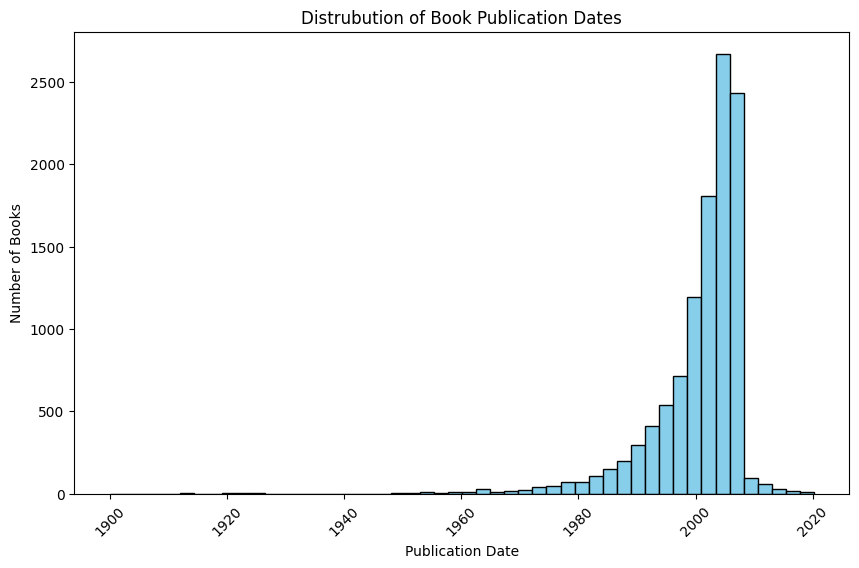

In [18]:
book_review['publication_date'] = pd.to_datetime(book_review['publication_date'], errors= 'coerce')

plt.figure(figsize=(10,6))
plt.hist(book_review['publication_date'],bins=50,color='skyblue',edgecolor='black')
plt.title('Distrubution of Book Publication Dates')
plt.xlabel('Publication Date')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.show()



According to the graph the density of the number published books rises around the years 2000 - 2010.

**Highest rated books in the year with the biggest number of books published**

In [19]:

book_review['publication_year'] = book_review['publication_date'].dt.year
book_review['publication_year'].value_counts()


publication_year
2006.0    1700
2005.0    1260
2004.0    1069
2003.0     931
2002.0     798
          ... 
1947.0       1
1922.0       1
1929.0       1
1919.0       1
1940.0       1
Name: count, Length: 87, dtype: int64

**Top rated books in the year 2006**

In [20]:
#There were 1700 books published in 2006 which is greatet amount across all years
the_year= book_review[book_review['publication_date'].dt.year == 2006]
top_rated_2006 = the_year.sort_values(by='average_rating', ascending=False)
list_top_rated_2006 = top_rated_2006[['title','authors','publication_date','average_rating']]
list_top_rated_2006.head(10)



,title,authors,publication_date,average_rating
bookID,,,,
2560,Willem de Kooning: Late Paintings,Julie Sylvester/David Sylvester,2006-09-01,5.00
17224,The Diamond Color Meditation: Color Pathway to...,John Diamond,2006-02-01,5.00
39382,Corvette,Jerry Burton,2006-10-01,4.83
17277,The Feynman Lectures on Physics Vols 7-8,Richard P. Feynman,2006-01-03,4.80
6550,Early Color,Saul Leiter/Martin Harrison,2006-01-15,4.73
39201,Getting a Grip on the Basics: Building a Firm ...,Beth A. Jones,2006-05-01,4.67
12789,Falling Angels (Luc Actar #1),Melissa M. Garcia,2006-02-14,4.67
23753,The Absolute Sandman Volume One,Neil Gaiman/Mike Dringenberg/Chris Bachalo/Mic...,2006-11-01,4.65
23589,The J.R.R. Tolkien Companion and Guide,Christina Scull/Wayne G. Hammond,2006-11-02,4.64


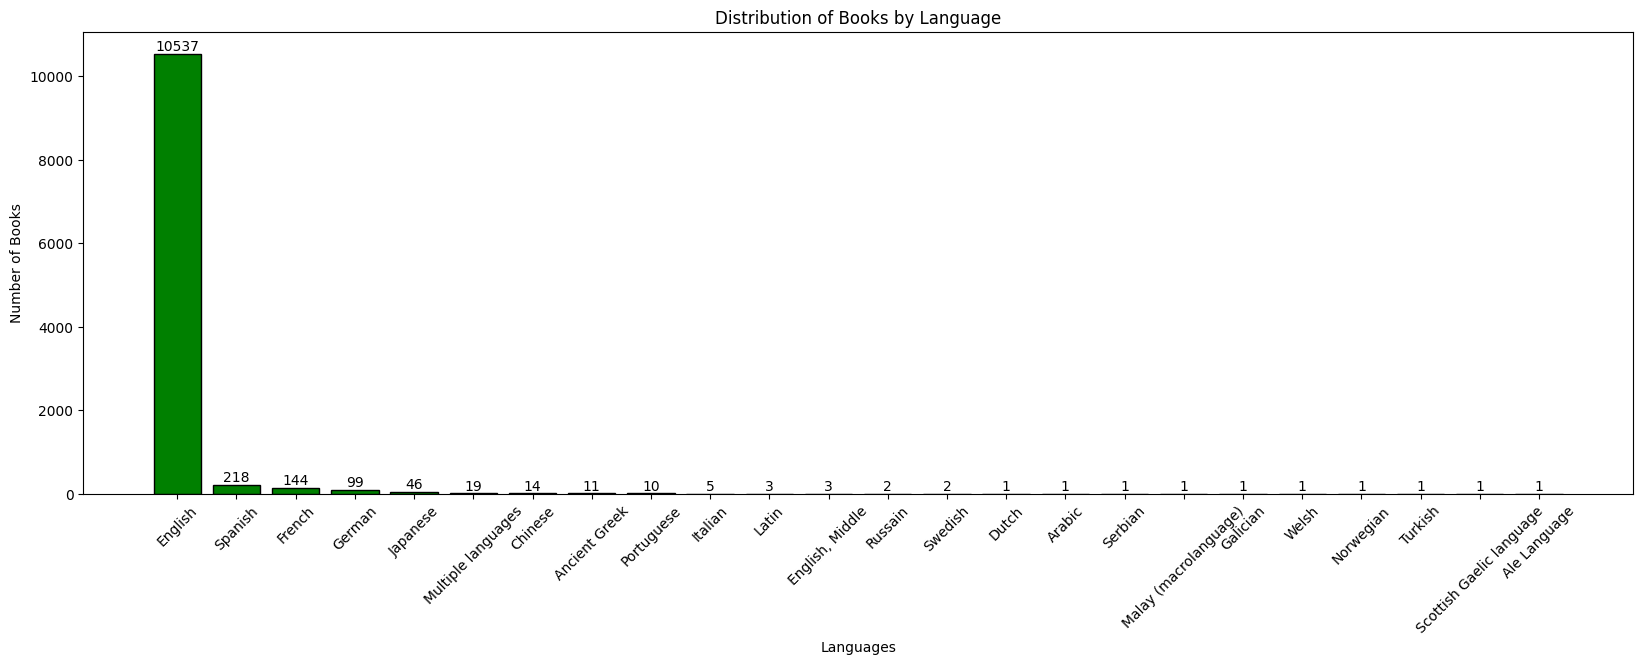

In [21]:
#Moving onto the language column

language_dist = book_review['language'].value_counts()
plt.figure(figsize=(20, 6))
bars = plt.bar(language_dist.index, language_dist.values, color='green', edgecolor='black')
plt.title('Distribution of Books by Language')
plt.xlabel('Languages')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(int(height)), ha='center', va='bottom', fontsize=10)

plt.show()


In [22]:
author_count = book_review['authors'].value_counts().head(10)
author_count.head(10)

authors
Stephen King        40
P.G. Wodehouse      40
Rumiko Takahashi    39
Orson Scott Card    35
Agatha Christie     33
Piers Anthony       30
Sandra Brown        29
Mercedes Lackey     29
Dick Francis        28
Terry Pratchett     23
Name: count, dtype: int64

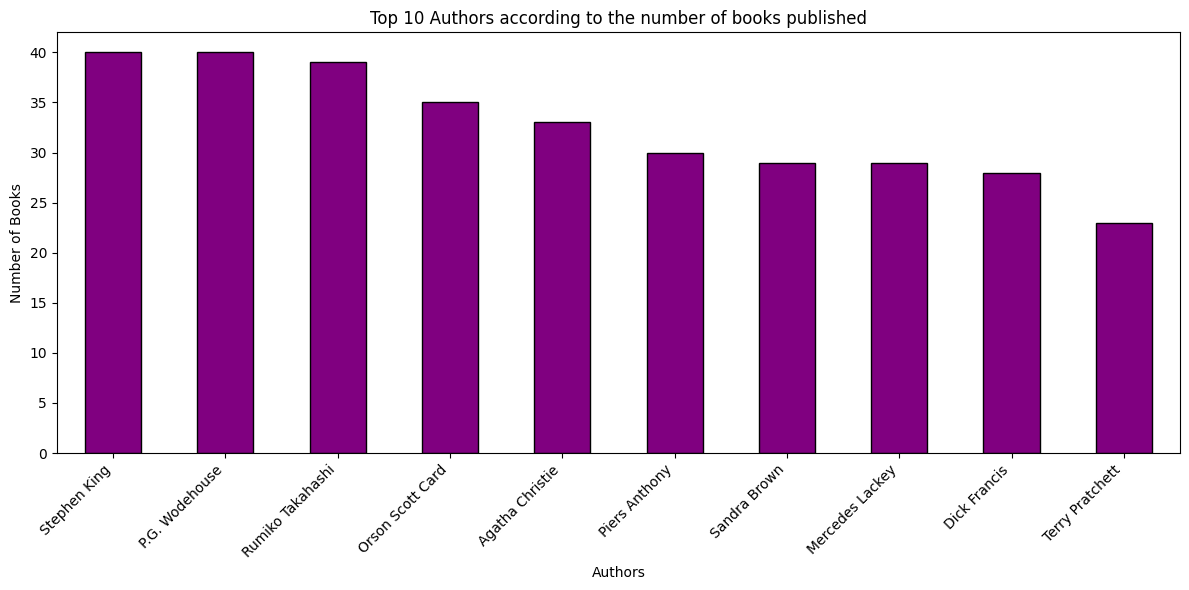

In [23]:

plt.figure(figsize=(12,6))
author_count.plot(kind='bar',color='purple', edgecolor='black')
plt.title('Top 10 Authors according to the number of books published')
plt.xlabel('Authors')
plt.ylabel('Number of Books')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

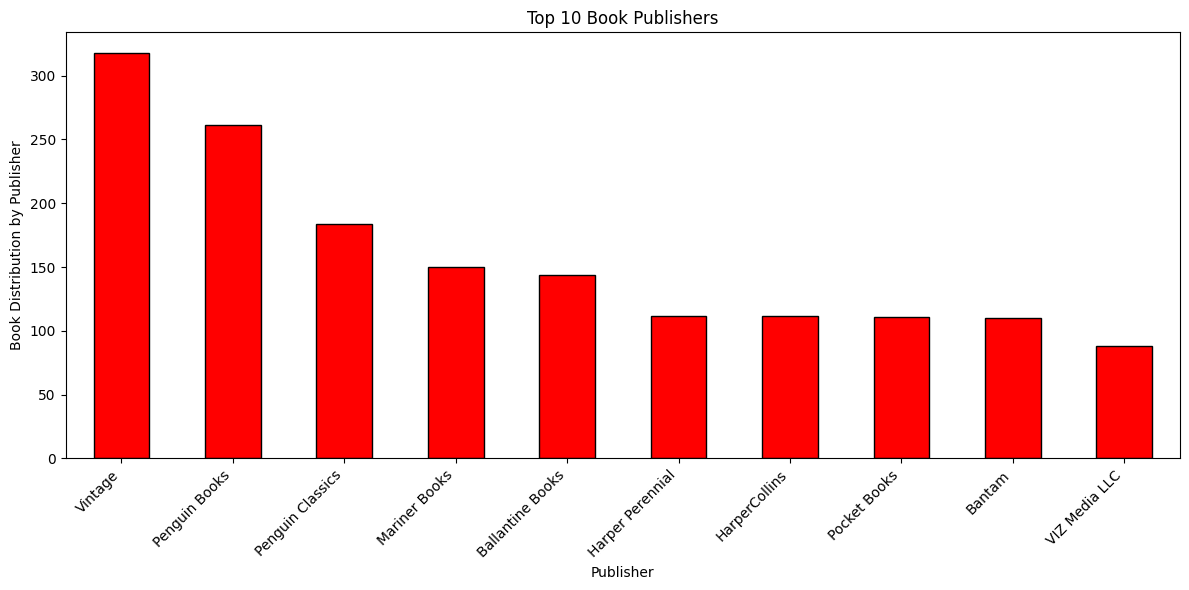

In [24]:
publisher_count = book_review['publisher'].value_counts().head(10)
publisher_count.head(10)
plt.figure(figsize=(12,6))
publisher_count.plot(kind='bar',color='red', edgecolor='black')
plt.title('Top 10 Book Publishers')
plt.xlabel('Publisher')
plt.ylabel('Book Distribution by Publisher')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()
# Top ten publishers based on their number of published books


In [54]:
year_counts = book_review['publication_year'].value_counts().sort_index()  


years = year_counts.index.to_numpy() 
num_books = year_counts.values  

print(years[:100]) 
print(num_books[:100]) 


[1900. 1913. 1914. 1919. 1921. 1922. 1923. 1925. 1928. 1929. 1931. 1935.
 1940. 1943. 1947. 1948. 1949. 1950. 1952. 1953. 1954. 1955. 1956. 1957.
 1958. 1959. 1960. 1961. 1962. 1963. 1964. 1965. 1966. 1967. 1968. 1969.
 1970. 1971. 1972. 1973. 1974. 1975. 1976. 1977. 1978. 1979. 1980. 1981.
 1982. 1983. 1984. 1985. 1986. 1987. 1988. 1989. 1990. 1991. 1992. 1993.
 1994. 1995. 1996. 1997. 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005.
 2006. 2007. 2008. 2009. 2010. 2011. 2012. 2013. 2014. 2015. 2016. 2017.
 2018. 2019. 2020.]
[   1    1    1    1    2    1    1    2    1    1    1    1    1    1
    1    1    3    2    2    2    4    4    3    3    4    5    6    5
    3    9   17    9    4    3    6   11   13   11   14   16   12   16
   31   34   24   32   26   31   44   36   73   62   72   88   77  118
  117  151  183  165  220  249  250  290  396  450  533  656  798  931
 1069 1260 1700  518   49   42   37   24   21   15    9   10    6    7
    5    6    1]


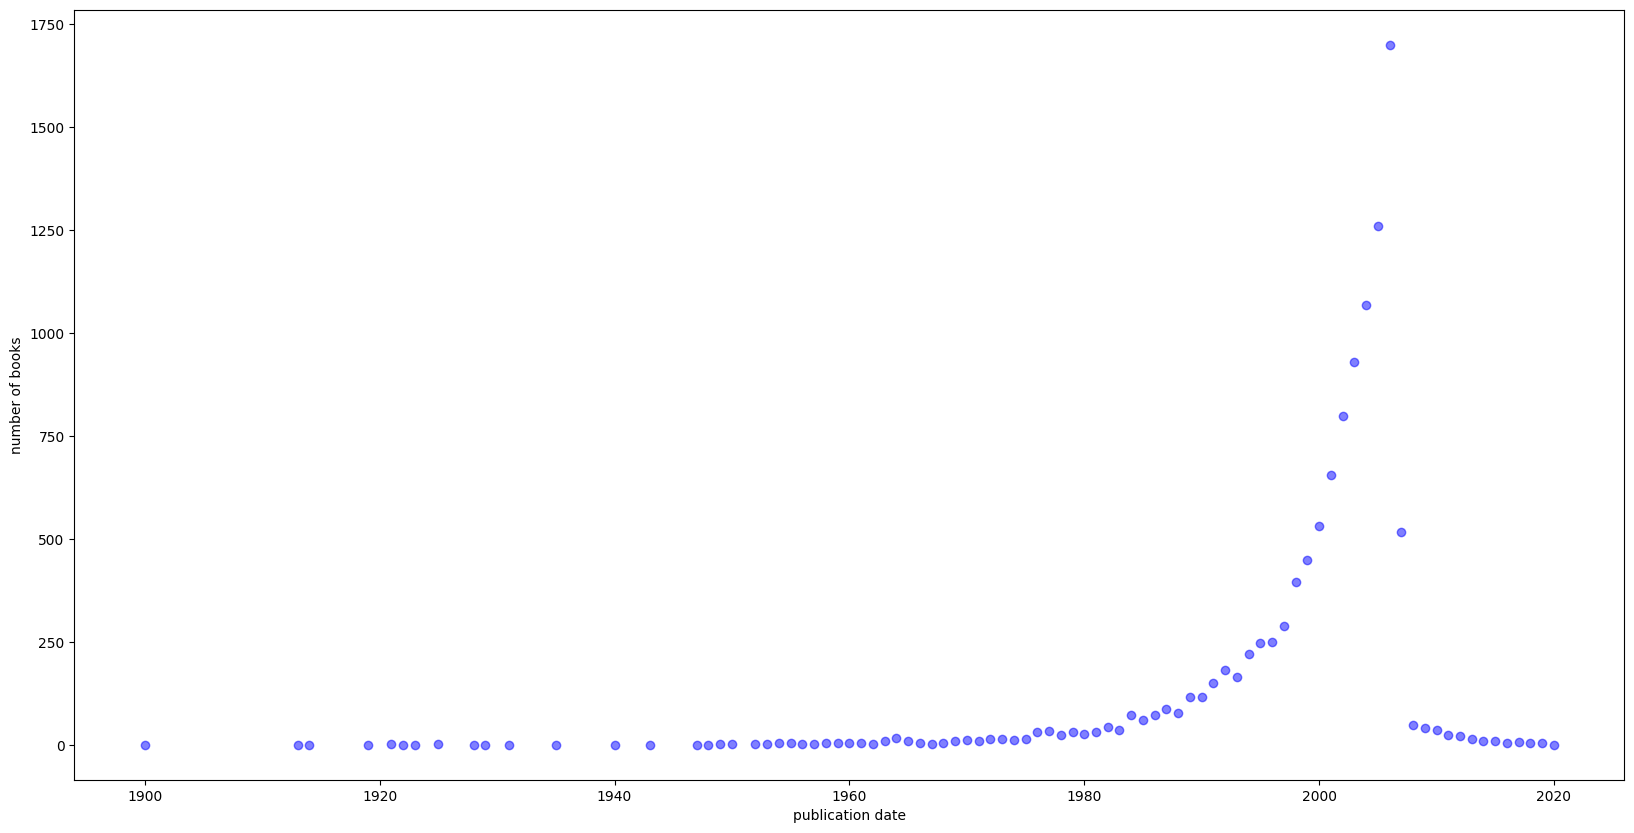

In [58]:
plt.figure(figsize=(20,10))
plt.scatter(years, num_books, alpha=0.5, c="blue")
plt.xlabel('publication date')
plt.ylabel('number of books')
plt.show()
#apply an algo to predict number of books published in any given year